In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost', 'pyarrow', 'polars'])
import os, gc
import pickle
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import xgboost as xgb
import polars as pl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Cập nhật đường dẫn theo chuẩn Kaggle
INPUT_DIR = '/kaggle/input/datasets/b22dckh072/file05/' 
TRAIN_PATH = os.path.join(INPUT_DIR, 'train_interactions.parquet')
META_PATH  = os.path.join(INPUT_DIR, 'filtered_metadata.parquet')
CAND_PATH  = os.path.join(INPUT_DIR, 'candidates_phase2.parquet')
FEAT_OUT   = os.path.join(INPUT_DIR, 'features.parquet')
TEST_PATH  = os.path.join(INPUT_DIR, 'test_interactions.parquet')

FEATURES = [
    'user_total_actions', 
    'item_total_sales', 
    'price', 
    'average_rating',
    'rating_number',
    'user_avg_rating_given',
    'item_actual_avg_rating',  
    'item_verified_ratio',      # Tỷ lệ mua thật
    'item_log_helpful_votes',   # Điểm hữu ích (Log)
    'store',                    # Tên thương hiệu (Categorical)
    'category_last_word',       #  Loại trang phục (Categorical)
    'sasrec_score', 
    'lightgcn_score'
]

Đang nạp file đặc trưng bằng Polars (Siêu tiết kiệm RAM)...
Đang chuyển qua Pandas và khóa từ điển Categorical...
Đang sắp xếp dữ liệu theo User ID (Yêu cầu bắt buộc của XGBoost Ranker)...
Đã lưu từ điển tại /kaggle/working/category_dict.pkl
Đang chuyển đổi cấu trúc dữ liệu cho XGBoost...
-> Số cây tối ưu (tránh Overfit): 158
Tiến hành huấn luyện mô hình chính thức...
Huấn luyện hoàn tất! Đã lưu mô hình tại: /kaggle/working/xgboost_ranking_model.json


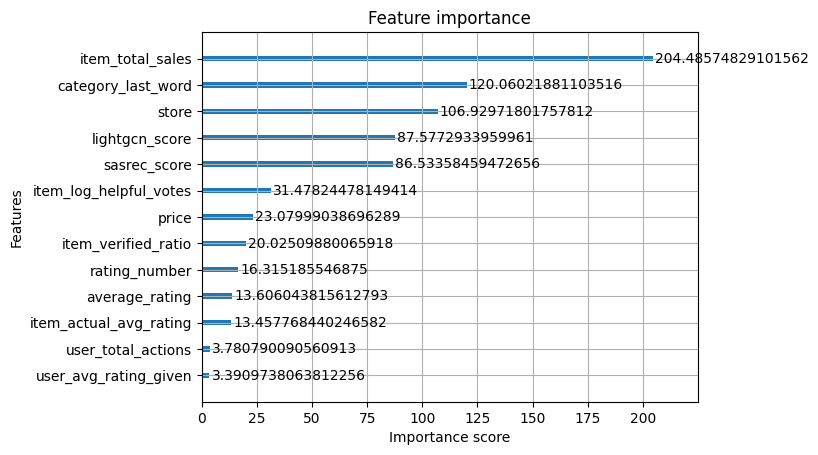

5241

In [2]:
print("Đang nạp file đặc trưng bằng Polars (Siêu tiết kiệm RAM)...")
# Đọc file bằng Polars thay vì Pandas
df_train = pl.read_parquet(FEAT_OUT)

# CHÚ Ý: Cần lấy thêm 'mapped_user_id' để làm Query ID (qid) cho thuật toán Ranking
X_train = df_train.select(FEATURES + ['mapped_user_id'])
y_train = df_train.select(['label'])

print("Đang chuyển qua Pandas và khóa từ điển Categorical...")
X_train_pd = X_train.to_pandas()
y_train_pd = y_train.to_pandas()

# BẮT BUỘC CHO RANKING: Sắp xếp dữ liệu theo mapped_user_id để gom nhóm các query lại với nhau
print("Đang sắp xếp dữ liệu theo User ID (Yêu cầu bắt buộc của XGBoost Ranker)...")
X_train_pd['label'] = y_train_pd['label'] # Gắn tạm label vào để sort đồng bộ
X_train_pd = X_train_pd.sort_values('mapped_user_id').reset_index(drop=True)

# Tách lại y_train_pd sau khi sort
y_train_pd = X_train_pd[['label']]
# Tách qid (Mã khách hàng)
qid_train = X_train_pd['mapped_user_id']
# Loại bỏ các cột không phải Feature ra khỏi tập X
X_train_pd = X_train_pd.drop(columns=['mapped_user_id', 'label'])

# Ép kiểu chuẩn bằng Pandas
X_train_pd['store'] = X_train_pd['store'].astype(str).astype('category')
X_train_pd['category_last_word'] = X_train_pd['category_last_word'].astype(str).astype('category')

# LƯU BỘ TỪ ĐIỂN CHUẨN RA ĐĨA CỨNG ĐỂ DÙNG CHO FILE 07
with open('/kaggle/working/category_dict.pkl', 'wb') as f:
    pickle.dump({
        'store': X_train_pd['store'].cat.categories,
        'category_last_word': X_train_pd['category_last_word'].cat.categories
    }, f)
print("Đã lưu từ điển tại /kaggle/working/category_dict.pkl")

print("Đang chuyển đổi cấu trúc dữ liệu cho XGBoost...")
# TRỌNG TÂM: Thêm tham số qid vào DMatrix để XGBoost biết cách so sánh theo từng User
dtrain = xgb.DMatrix(X_train_pd, label=y_train_pd, qid=qid_train, enable_categorical=True)

# Giải phóng RAM
del X_train_pd, y_train_pd, df_train, X_train, y_train, qid_train
gc.collect()

constraints = {
    'sasrec_score': 1,    
    'lightgcn_score': 1   
}

params = {
    'tree_method': 'hist',       
    'device': 'cuda',            
    'objective': 'rank:pairwise', 
    'eval_metric': 'ndcg', 
    'max_depth': 6,                
    'learning_rate': 0.1,
    
    'colsample_bytree': 0.5,       
    'subsample': 0.8,
    'monotone_constraints': constraints
}

cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=500, 
    nfold=3,            
    early_stopping_rounds=20, 
    metrics='ndcg',
    seed=42,
    verbose_eval=False
)

# Lấy số vòng lặp tốt nhất
best_num_trees = cv_results.shape[0]
print(f"-> Số cây tối ưu (tránh Overfit): {best_num_trees}")

print("Tiến hành huấn luyện mô hình chính thức...")
model = xgb.train(params, dtrain, num_boost_round=best_num_trees)

# Lưu mô hình
model_path = '/kaggle/working/xgboost_ranking_model.json'
model.save_model(model_path)
print(f"Huấn luyện hoàn tất! Đã lưu mô hình tại: {model_path}")

# Trực quan hóa độ quan trọng của đặc trưng
xgb.plot_importance(model, importance_type='gain')
plt.show()

# Dọn dẹp RAM cho các bước sau
del dtrain
gc.collect()

In [3]:
import polars as pl

# Trỏ đến file features.parquet mà File 06 dùng để huấn luyện
FEAT_OUT = '/kaggle/input/datasets/b22dckh072/file05/features.parquet' 

print("Đang quét X-quang tập dữ liệu Huấn luyện (Train Data)...")
df_train = pl.read_parquet(FEAT_OUT)

# Thống kê điểm trung bình của SASRec và LightGCN chia theo Nhãn (Mua thật vs Không mua)
stats = df_train.group_by('label').agg([
    pl.len().alias('Tổng số dòng'),
    pl.col('sasrec_score').mean().alias('Điểm SASRec (TB)'),
    pl.col('lightgcn_score').mean().alias('Điểm LightGCN (TB)'),
    (pl.col('sasrec_score') == 0).sum().alias('Số món bị 0 điểm SASRec'),
]).sort('label', descending=True)

print(stats)

Đang quét X-quang tập dữ liệu Huấn luyện (Train Data)...
shape: (2, 5)
┌───────┬──────────────┬──────────────────┬────────────────────┬─────────────────────────┐
│ label ┆ Tổng số dòng ┆ Điểm SASRec (TB) ┆ Điểm LightGCN (TB) ┆ Số món bị 0 điểm SASRec │
│ ---   ┆ ---          ┆ ---              ┆ ---                ┆ ---                     │
│ i8    ┆ u32          ┆ f32              ┆ f32                ┆ u32                     │
╞═══════╪══════════════╪══════════════════╪════════════════════╪═════════════════════════╡
│ 1     ┆ 49043        ┆ 138.505417       ┆ 144.960693         ┆ 7089                    │
│ 0     ┆ 2064056      ┆ 109.639313       ┆ 106.305328         ┆ 503783                  │
└───────┴──────────────┴──────────────────┴────────────────────┴─────────────────────────┘


In [4]:
import polars as pl

# Đọc file dữ liệu đã tạo
df_train = pl.read_parquet(FEAT_OUT)

# Chỉ lọc ra những món khách hàng thực sự mua (Nhãn 1)
positives = df_train.filter(pl.col('label') == 1)

print("Tổng số món khách mua thật (Nhãn 1):", positives.height)
print("Số món do SASRec đoán trúng (Score > 0):", positives.filter(pl.col('sasrec_score') > 0.0).height)
print("Số món do LightGCN đoán trúng (Score > 0):", positives.filter(pl.col('lightgcn_score') > 0.0).height)

Tổng số món khách mua thật (Nhãn 1): 49043
Số món do SASRec đoán trúng (Score > 0): 41954
Số món do LightGCN đoán trúng (Score > 0): 42078
